In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from torch.utils.data import random_split
import astropy.constants as c
import astropy.units as u

class VectorScalarDataset(Dataset):
    def __init__(self, X, y):
        """
        X: Tensor of shape (N, p) — inputs
        y: Tensor of shape (N,)   — scalar targets
        """
        self.X = X.float()
        self.y = y.float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

def cd_sed(nu, Beta, T, a=1):
    nu_c = 545 #GHz
    h_over_k = (c.h/c.k_B/(1*u.K)).to('GHz-1').value
    return a*(nu/nu_c)**(Beta+1)*(np.exp(h_over_k*nu_c/T) - 1)/(np.exp(h_over_k*nu/T) - 1)

def integral(bp_shift, Beta, T, bp_dat):
    return np.sum(bp_dat[1]*cd_sed(bp_dat[0]+bp_shift, Beta, T))


class NeuralNet(nn.Module):
    def __init__(self, input_size:int=3, hidden_size:int=8, n_hidden:int=3, hidden_func=torch.relu):
        super(NeuralNet, self).__init__()
        assert n_hidden >= 1, "NN must have at least one hidden layer"
        self.in_l = nn.Linear(input_size, hidden_size)   # input layer (3 -> N)
        for l in range(n_hidden):
            setattr(self, f"hl_{l+1}", nn.Linear(hidden_size, hidden_size)) # hidden layers (N -> N)
        self.out_l = nn.Linear(hidden_size, 1)            # output layer (N -> 1 value)
        self.hidden_f = hidden_func
        self.h_size = hidden_size
        self.n_hidden = n_hidden
        self.in_size = input_size

    def forward(self, x):
        x = self.hidden_f(self.in_l(x))       # hidden layer 1 + ReLU activation, maybe try gelu
        for l in range(self.n_hidden):
            x = self.hidden_f(getattr(self, f"hl_{l+1}")(x))
        x = self.out_l(x).squeeze(-1)       # output layer (reduce to 1 value)
        return x
    
    @property
    def flops(self):
        count = 2*self.in_size*self.h_size \
                + 2*self.n_hidden*self.h_size**2 \
                + 2*self.h_size
        return count
    
# class NeuralNet(nn.Module):
#     def __init__(self, dimensions:tuple[int], hidden_func=torch.relu):
#         super(NeuralNet, self).__init__()
#         i = 0
#         assert len(dimensions) > 1, "The NN can not have less than 2 layers" 
#         for dim in dimensions:
#             setattr(self, f"fc_{i}", )
#         self.fc1 = nn.Linear(input_size, hidden_size)   # first hidden layer (3 -> N)
#         self.fc2 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
#         self.fc3 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
#         self.fc4 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
#         self.fc5 = nn.Linear(hidden_size, 1)            # output layer (N -> 1 value)
#         self.hidden_f = hidden_func

#     def forward(self, x):
#         x = self.hidden_f(self.fc1(x))       # hidden layer 1 + ReLU activation, maybe try gelu
#         x = self.hidden_f(self.fc2(x))       # hidden layer 2 + ReLU activation
#         x = self.hidden_f(self.fc3(x))       # hidden layer 2 + ReLU activation
#         x = self.hidden_f(self.fc4(x))       # hidden layer 2 + ReLU activation
#         x = self.fc5(x).squeeze(-1)       # output layer (reduce to 1 value)
#         return x
    
#     def FLOPs_count(self):
#         count = 2*self.fc1.in_features*self.fc1.out_features
#         count += 2*self.fc2.in_features*self.fc2.out_features
#         count += 2*self.fc3.in_features*self.fc3.out_features
#         count += 2*self.fc4.in_features*self.fc4.out_features
#         count += 2*self.fc5.in_features*self.fc5.out_features
#         return count

class FFNN:
    """
    Description:
    ------------
        Wrapper class for a Feed Forward neural network designed for interpolating the 
        smooth bandpass integral.

    Attributes:
    ------------
        - dimensions (tuple[int]): A list of positive integers, which specifies the
            number of nodes in each of the networks layers. The first integer in the array
            defines the number of nodes in the input layer, the second integer defines number
            of nodes in the first hidden layer and so on until the last number, which
            specifies the number of nodes in the output layer.
        - hidden_func (Callable): The activation function for the hidden layers
        - loss_criterion (torch.nn.Module): Cost function criterion 
        - optimizer (torch.optim.Optimizer): Optimizer to be used for training the network
        - learning_rate (float): learning rate used for training the network 
    """

    def __init__(
        self,
        input_size:int=3, 
        hidden_size:int=8, 
        n_hidden:int=3, 
        hidden_func:callable=torch.relu,
        loss_criterion:nn.Module=nn.HuberLoss,
        optimizer:optim.Optimizer=optim.Adam
        ):
        self.torchNN = NeuralNet(input_size=input_size,
                                 hidden_size=hidden_size,
                                 n_hidden=n_hidden,
                                 hidden_func=hidden_func)
        self.loss_criterion = loss_criterion
        self.optim = optimizer
    
    def fit(
        self, 
        dataset:VectorScalarDataset, 
        normalize_y:bool=True, 
        epochs:int=50, 
        batch_size:int=64, 
        learning_rate:float=1e-4,
        validation_rel_size:float=0.2
        ):
        """
        fits the model on a dataset training the underlying NN. The dataset is authomatically split
        into training and validation datasets.
        """
        if normalize_y:
            y_mean, y_std = dataset.y.mean(), dataset.y.std()
            dataset.y  = (dataset.y - y_mean) / y_std
        len_tot = len(dataset)
        val_size   = int(validation_rel_size * len_tot)
        train_size = len_tot - val_size
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
        val_loader  = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
        



In [40]:
# Device configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_data = torch.load("dataset_train.pt")
test_data = torch.load("dataset_val.pt")

y_mean = train_data["y"].mean()
y_std  = train_data["y"].std()

y_mean_test = test_data["y"].mean()
y_std_test  = test_data["y"].std()

print("TRAINING DATASET, parameters order:")
print(f"Bandpass shift: mean={train_data['X'][:,0].mean():.2f}, std={train_data['X'][:,0].std():.2f}")
print(f"          Beta: mean={train_data['X'][:,1].mean():.2f}, std={train_data['X'][:,1].std():.2f}")
print(f"             T: mean={train_data['X'][:,2].mean():.2f}, std={train_data['X'][:,2].std():.2f}")
print(f"y mean: {y_mean:.2f}")
print(f"y std:  {y_std:.2f}")

# Normalize
y_train_norm = (train_data["y"] - y_mean) / y_std
y_test_norm = (test_data["y"] - y_mean) / y_std

dataset = VectorScalarDataset(train_data["X"], y_train_norm)
test_dataset = VectorScalarDataset(test_data["X"], test_data["y"])

total = len(dataset)
val_size   = int(0.2 * total)
train_size = total - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader  = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

model = NeuralNet().to(device)

print("MODEL:")
print(model)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total}")
print(f"Total FLOPs: {model.flops}")

criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) #, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=3, verbose=True
# )

TRAINING DATASET, parameters order:
Bandpass shift: mean=-0.29, std=5.79
          Beta: mean=1.90, std=0.17
             T: mean=12.00, std=1.16
y mean: 867.58
y std:  5.39
MODEL:
NeuralNet(
  (in_l): Linear(in_features=3, out_features=8, bias=True)
  (hl_1): Linear(in_features=8, out_features=8, bias=True)
  (hl_2): Linear(in_features=8, out_features=8, bias=True)
  (hl_3): Linear(in_features=8, out_features=8, bias=True)
  (out_l): Linear(in_features=8, out_features=1, bias=True)
)
Trainable parameters: 257
Total FLOPs: 448


In [41]:
#Train
if True:
    num_epochs = 50
    avg_t_loss_s = np.zeros(num_epochs)
    avg_v_loss_s = np.zeros(num_epochs)
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)      # move inputs to GPU
            y_batch = y_batch.to(device)      # move targets to GPU

            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * len(y_batch)

        # --- Validation ---
        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)  # move inputs to GPU
                y_batch = y_batch.to(device)  # move targets to GPU

                preds = model(X_batch)
                loss  = criterion(preds, y_batch)
                total_val_loss += loss.item() * len(y_batch)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        avg_val_loss   = total_val_loss   / len(val_loader.dataset)
        avg_t_loss_s[epoch] = avg_train_loss
        avg_v_loss_s[epoch] = avg_val_loss
        print(f"Epoch {epoch+1}: train={avg_train_loss:.4f}  val={avg_val_loss:.4f}")


Epoch 1: train=0.2032  val=0.1091
Epoch 2: train=0.0516  val=0.0099
Epoch 3: train=0.0058  val=0.0034
Epoch 4: train=0.0029  val=0.0028
Epoch 5: train=0.0028  val=0.0028
Epoch 6: train=0.0027  val=0.0029
Epoch 7: train=0.0027  val=0.0027
Epoch 8: train=0.0026  val=0.0027
Epoch 9: train=0.0026  val=0.0026
Epoch 10: train=0.0026  val=0.0026
Epoch 11: train=0.0025  val=0.0024
Epoch 12: train=0.0025  val=0.0024
Epoch 13: train=0.0024  val=0.0025
Epoch 14: train=0.0024  val=0.0024
Epoch 15: train=0.0023  val=0.0022
Epoch 16: train=0.0023  val=0.0022
Epoch 17: train=0.0022  val=0.0022
Epoch 18: train=0.0022  val=0.0022
Epoch 19: train=0.0022  val=0.0022
Epoch 20: train=0.0022  val=0.0021
Epoch 21: train=0.0022  val=0.0021
Epoch 22: train=0.0022  val=0.0022
Epoch 23: train=0.0022  val=0.0022
Epoch 24: train=0.0021  val=0.0021
Epoch 25: train=0.0021  val=0.0021
Epoch 26: train=0.0021  val=0.0021
Epoch 27: train=0.0021  val=0.0021
Epoch 28: train=0.0021  val=0.0020
Epoch 29: train=0.0020  val=0

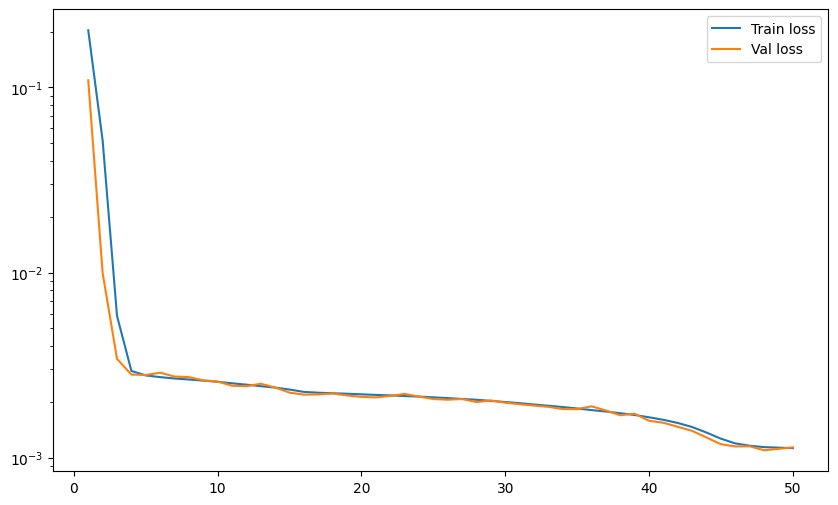

In [43]:
plt.figure(figsize=(10,6))
plt.plot(np.arange(1, num_epochs+1), avg_t_loss_s, label="Train loss")
plt.plot(np.arange(1, num_epochs+1), avg_v_loss_s, label="Val loss")
plt.yscale('log')
plt.savefig("training.png")
plt.legend()
plt.close

if True:
    torch.save({
        'model_state_dict': model.state_dict(),
        'y_mean': y_mean,
        'y_std':  y_std,
        }, 'bandpass_NN_v3.pth')

In [44]:
#Evaluation on the Test Set

model = NeuralNet()    # instantiate architecture first
model_setup_dict = torch.load('bandpass_NN_v3.pth', map_location=device)
model.load_state_dict(model_setup_dict['model_state_dict'])
y_std, y_mean = model_setup_dict['y_std'], model_setup_dict['y_mean'] 
model.to(device)
model.eval()


NeuralNet(
  (in_l): Linear(in_features=3, out_features=8, bias=True)
  (hl_1): Linear(in_features=8, out_features=8, bias=True)
  (hl_2): Linear(in_features=8, out_features=8, bias=True)
  (hl_3): Linear(in_features=8, out_features=8, bias=True)
  (out_l): Linear(in_features=8, out_features=1, bias=True)
)

In [45]:
with torch.no_grad():
    # Single sample
    errs = []
    total_val_loss = 0
    for X_batch, y_batch in test_loader:
        X_batch = X_batch #.to(device)  # move inputs to GPU
        y_batch = y_batch #.to(device)  # move targets to GPU
        X_b0 = X_batch[0]
        pred_norm = model(X_b0)
        pred = pred_norm * y_std + y_mean           # denormalize output
        err = abs((pred - y_batch[0].item()))/y_batch[0].item()
        print(f"Params: [{X_b0[0]}, {X_b0[1]}, {X_b0[2]}], Preds = {pred.item():.4f}, True = {y_batch[0].item():.4f}, err = {err}")
        errs.append(err)
        loss  = criterion(pred, y_batch)
        total_val_loss += loss.item() * len(y_batch)

Params: [-10.0, 1.600000023841858, 10.0], Preds = 863.1078, True = 863.6838, err = 0.0006668807346968003
Params: [-10.0, 1.6571428775787354, 13.809523582458496], Preds = 862.4321, True = 861.8459, err = 0.0006800773996881529
Params: [-10.0, 1.7428570985794067, 13.428571701049805], Preds = 862.0811, True = 861.5145, err = 0.0006576781156144625
Params: [-10.0, 1.8285714387893677, 13.047618865966797], Preds = 861.7302, True = 861.1963, err = 0.0006199374370190265
Params: [-10.0, 1.914285659790039, 12.666666984558105], Preds = 861.3792, True = 860.8893, err = 0.0005690540762737419
Params: [-10.0, 2.0, 12.285714149475098], Preds = 861.0283, True = 860.5916, err = 0.0005074076629754751
Params: [-10.0, 2.085714340209961, 11.904762268066406], Preds = 860.7638, True = 860.3010, err = 0.0005379653201081605
Params: [-10.0, 2.171428680419922, 11.523809432983398], Preds = 860.5008, True = 860.0154, err = 0.0005643145166111104
Params: [-9.047618865966797, 1.6285713911056519, 11.142857551574707], Pre

/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([24])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


/tmp/ipykernel_19048/3159281034.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


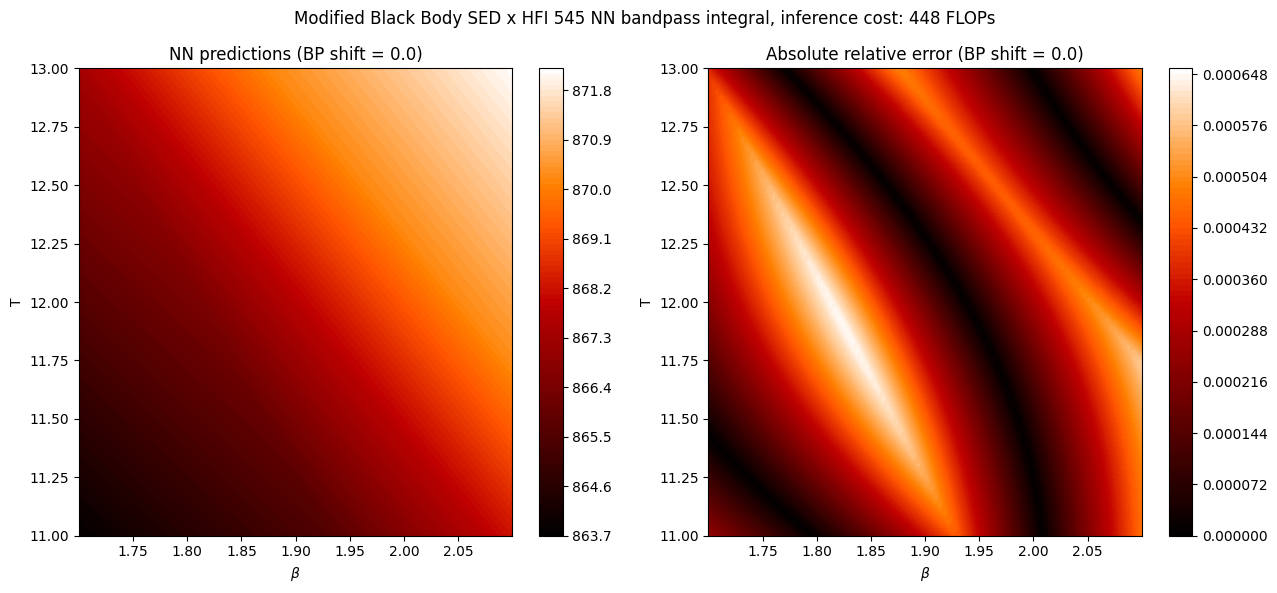

In [46]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s_fixed = 0.0 

grid_b, grid_t = torch.meshgrid(beta_s, t_s, indexing='ij')

X_grid = torch.stack([
    torch.full((N_vals*N_vals,), bp_s_fixed),
    grid_b.flatten(),
    grid_t.flatten()
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_b.numpy(),         # x axis  shape: (100, 100)
    grid_t.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel(r'$\beta$')
ax[0].set_ylabel('T')
ax[0].set_title(f'NN predictions (BP shift = {bp_s_fixed})')

cf = ax[1].contourf(
    grid_b.numpy(),       # x axis  shape: (100, 100)
    grid_t.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel('T')
ax[1].set_title(f'Absolute relative error (BP shift = {bp_s_fixed})')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19048/2685985339.py:56: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


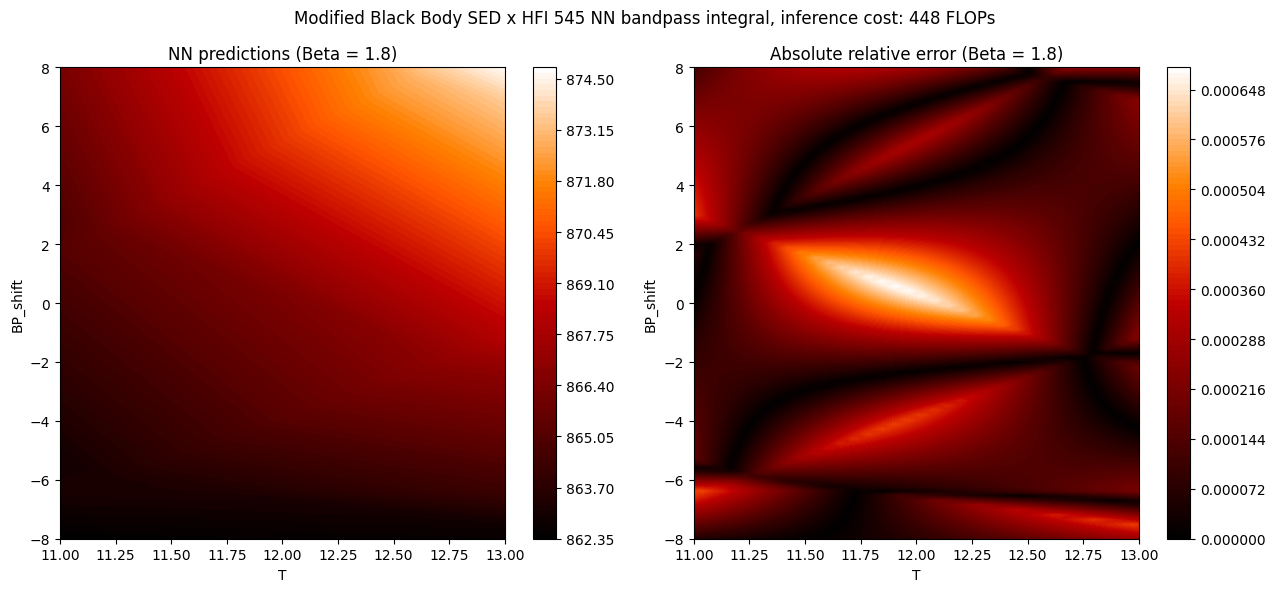

In [47]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_fixed = 1.8
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s = torch.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], N_vals)

grid_t, grid_bps = torch.meshgrid(t_s, bp_s, indexing='ij')

X_grid = torch.stack([
    grid_bps.flatten(),
    torch.full((N_vals*N_vals,), beta_fixed),
    grid_t.flatten()
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))

trues_grid=np.array(all_true).reshape((N_vals,N_vals))


#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_t.numpy(),         # x axis  shape: (100, 100)
    grid_bps.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel('T')
ax[0].set_ylabel('BP_shift')
ax[0].set_title(f'NN predictions (Beta = {beta_fixed})')

cf = ax[1].contourf(
    grid_t.numpy(),       # x axis  shape: (100, 100)
    grid_bps.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel('T')
ax[1].set_ylabel('BP_shift')
ax[1].set_title(f'Absolute relative error (Beta = {beta_fixed})')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19048/2198155001.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


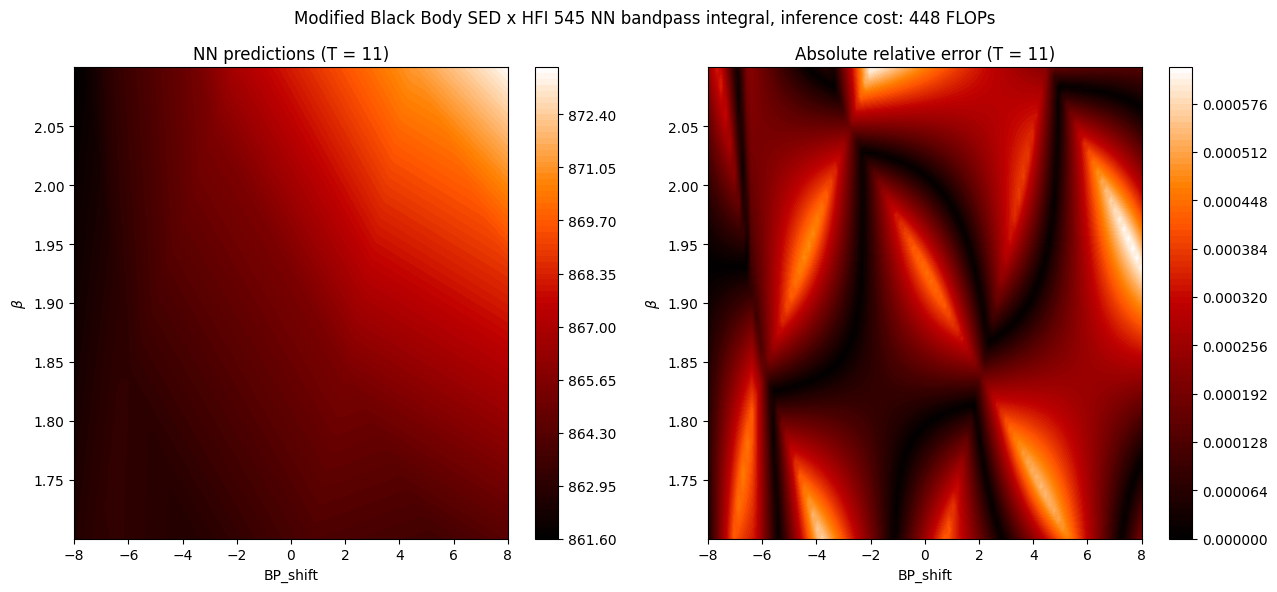

In [48]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
T_fixed = 11
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
bp_s = torch.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], N_vals)

grid_bps, grid_beta = torch.meshgrid(bp_s, beta_s, indexing='ij')

X_grid = torch.stack([
    grid_bps.flatten(),
    grid_beta.flatten(),
    torch.full((N_vals*N_vals,), T_fixed)
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_bps.numpy(),         # x axis  shape: (100, 100)
    grid_beta.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel('BP_shift')
ax[0].set_ylabel(r'$\beta$')
ax[0].set_title(f'NN predictions (T = {T_fixed})')

cf = ax[1].contourf(
    grid_bps.numpy(),       # x axis  shape: (100, 100)
    grid_beta.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel('BP_shift')
ax[1].set_ylabel(r'$\beta$')
ax[1].set_title(f'Absolute relative error (T = {T_fixed})')
plt.tight_layout()
plt.show()